<a href="https://colab.research.google.com/github/MarinPedro/ThermalProject2026_HOCV/blob/main/SCV_P.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%%capture
!rm -rf /content/IHTest_202104_DistStA/
%mkdir -p /content/IHTest_202104_DistStA/test_data
%cd /content

Loading some data from the 202104 collection of the Darpa Invisible Headlights dataset

In [ ]:
%%capture
!pip install spectral
!pip install awscli -q
!pip install laspy

In [ ]:
%%capture
!aws s3 sync \
  s3://ihdataset-01/IHTest_202104_DistStA/Path15_DistStA/Path15_Step16_DistStA/ \
  /content/IHTest_202104_DistStA/test_data \
  --no-sign-request \
  --exclude "*" \
  --include "*Path15_Step16_BBVISRIGHT_DistStA.hdr" \
  --include "*Path15_Step16_BBVISRIGHT_DistStA.raw" \
  --include "*LWHSI1_collect1_DistStA.hdr" \
  --include "*LWHSI1_collect1_DistStA.bsq"

In [ ]:
%%capture
! rm -rf /content/IHTest_202104_DistStA/depth_data
%cd ..
! git clone -n --depth=1 --filter=tree:0 \
  https://github.com/MarinPedro/ThermalProject2026_HOCV /content/IHTest_202104_DistStA/depth_data
%cd /content/IHTest_202104_DistStA/depth_data
! git sparse-checkout set --no-cone depth
! git checkout
%cd ..

Loading the some data from Unay's GitHub for the scene

In [ ]:
%%capture
! rm -rf /content/attenuation
%cd ..
! git clone -n --depth=1 --filter=tree:0 \
  https://github.com/unaydorken/Ozone-Cues-Mitigate-Reflected-Downwelling-Radiance-in-LWIR-Absorption-Based-Ranging /content/attenuation
%cd /content/attenuation
! git sparse-checkout set --no-cone data/attenuation.mat data/I_downwelling_res.mat data/lambda.mat
! git checkout

Loading the Ecostress Spectral Library

In [ ]:
%%capture
! rm -rf /content/ecostress_spectral
%cd ..
! git clone -n --depth=1 --filter=tree:0 \
  https://github.com/MarinPedro/ThermalProject2026_HOCV /content/ecostress_spectral
%cd /content/ecostress_spectral
! git sparse-checkout set --no-cone ecostress
! git checkout

Importing libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import spectral.io.envi as envi
import glob
import plotly.graph_objects as go
from pathlib import Path
from sklearn.cluster import KMeans
from skimage.color import rgb2gray
from sklearn.cluster import KMeans
from skimage.transform import resize
import scipy.io as sio
from mpl_toolkits.axes_grid1 import make_axes_locatable

Implementing the functions used for the notebook

In [69]:
MICROFLICK_PER_W_M2 = 100.0

def robust_image(image, low=2, high=98):
    """Normalize an image for display using percentiles."""
    lo, hi = np.percentile(image, [low, high])
    return np.clip((image - lo) / (hi - lo + 1e-12), 0, 1)

def blackbody_radiance(wavelenghts_um, temperature_k):
    """Planck blackbody spectral radiance for all bands, in uW / (sr um cm^2)."""
    h = 6.62607015e-34
    c = 299792458.0
    k = 1.380649e-23

    wavelength_m = wavelengths_um * 1e-6

    x = (h * c) / (wavelength_m * k * temperature_k)

    radiance_w_m2_sr_um = (2.0 * h * c**2) / (wavelength_m**5 * np.expm1(x)) * 1e-6
    radiance_microflicks = radiance_w_m2_sr_um * MICROFLICK_PER_W_M2

    return radiance_microflicks.astype(np.float32)

def crop_valid_region(img, pad_rows=2, pad_cols=8):
    """
    Automatically crops the region containing valid measurements.
    This helps prevent images with too much empty space.
    """
    valid = np.isfinite(img)

    if not valid.any():
        return img

    rows = np.where(valid.any(axis=1))[0]
    cols = np.where(valid.any(axis=0))[0]

    r0 = max(0, rows.min() - pad_rows)
    r1 = min(img.shape[0], rows.max() + pad_rows + 1)
    c0 = max(0, cols.min() - pad_cols)
    c1 = min(img.shape[1], cols.max() + pad_cols + 1)

    return img[r0:r1, c0:c1]


def plot_range_image(
    range_img,
    title="Range image LiDAR — inverse depth (No fov calibration)",
    crop=True,
    inverse_depth=False,
    percentile_clip=(2, 98),
    figsize=(20, 3),
):
    """
    Cleaner visualization of a range image.

    crop=True crops the region containing data.
    inverse_depth=True displays 1/r closeness, useful for making nearby objects stand out.
    percentile_clip prevents extremely distant points from dominating the color scale.
    """
    img = range_img.copy()

    if crop:
        img = crop_valid_region(img)

    valid = np.isfinite(img)
    if not valid.any():
        print("There aren't valid meditions to render.")
        return

    if inverse_depth:
        img_to_show = np.full_like(img, np.nan, dtype=np.float32)
        img_to_show[valid] = 1.0 / img[valid]
        label = "Closeness 1 / distance [1/m]"
    else:
        img_to_show = img
        label = "Radial distance [m]"

    vmin, vmax = np.nanpercentile(img_to_show, percentile_clip)
    img_masked = np.ma.masked_invalid(img_to_show)

    cmap = plt.cm.viridis.copy()
    cmap.set_bad(color="black")

    plt.figure(figsize=figsize)
    plt.imshow(
        img_masked,
        cmap=cmap,
        aspect="auto",
        interpolation="nearest",
        vmin=vmin,
        vmax=vmax
    )
    plt.colorbar(label=label)
    plt.title(title)
    plt.xlabel("Horizontal angle / azimuth")
    plt.ylabel("Vertical angle / LiDAR channel")
    plt.tight_layout()
    plt.show()

def segmentation_maps(clusters, bbvis_image, lwhsi_image):
  num_clusters = clusters

  h, w, b = bbvis_image.shape
  X_rgb = bbvis_image[:, :, [0, 1, 2]].reshape(-1, 3)

  kmeans_rgb = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
  labels_rgb = kmeans_rgb.fit_predict(X_rgb)

  rgb_centers = kmeans_rgb.cluster_centers_

  rgb_brightness = rgb_centers.mean(axis=1)
  cluster_order_rgb = np.argsort(rgb_brightness)[::-1]

  h2, w2, b2 = lwhsi_image.shape
  X_lwhsi = lwhsi_image.reshape(-1, b2)

  kmeans_lwhsi = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
  labels_lwhsi = kmeans_lwhsi.fit_predict(X_lwhsi)
  labels_lwhsi_2d = labels_lwhsi.reshape(h2, w2)

  return h, w, h2, w2, rgb_centers, labels_rgb, kmeans_lwhsi, labels_lwhsi_2d

def emissivity_truth_map(
    h,
    w,
    h2,
    w2,
    rgb_centers,
    labels_rgb,
    kmeans_lwhsi,
    labels_lwhsi_2d,
    calibrationpoints_emissivity,
    soil_emissivity,
    leaves_emissivity,
    tree_emissivity,
    grass_emissivity,
    wavelengths_um,
    calibrationpoints_wavelength,
    soil_wavelength,
    leaves_wavelength,
    tree_wavelength,
    grass_wavelength
):

    rgb_segmented = rgb_centers[labels_rgb].reshape(h, w, 3)
    rgb_segmented_resized = resize(rgb_segmented, (h2, w2), anti_aliasing=False, order=0)

    emissivity_map = np.zeros((h2, w2, len(wavelengths_um)), dtype=np.float32)

    lwhsi_centers = kmeans_lwhsi.cluster_centers_
    lwhsi_brightness = lwhsi_centers.mean(axis=1)

    materials = [
        (soil_emissivity, soil_wavelength),
        (grass_emissivity, grass_wavelength),
        (leaves_emissivity, leaves_wavelength),
        (tree_emissivity, tree_wavelength),
        (calibrationpoints_emissivity, calibrationpoints_wavelength)
    ]

    def material_brightness(mat):
        emiss, _ = mat
        return np.mean(emiss) if isinstance(emiss, np.ndarray) else float(emiss)

    sorted_materials = sorted(materials, key=material_brightness)
    sorted_cluster_ids = np.argsort(lwhsi_brightness)


    cluster_mapping = {}
    for cluster_id, (val_emissivity, val_wavelengths) in zip(sorted_cluster_ids, sorted_materials):
        cluster_mapping[cluster_id] = (val_emissivity, val_wavelengths)

    for cluster_id, (val_emissivity, val_wavelengths) in cluster_mapping.items():

        if isinstance(val_emissivity, np.ndarray) and isinstance(val_wavelengths, np.ndarray):
            sort_idx = np.argsort(val_wavelengths)
            val_wavelengths_sorted = val_wavelengths[sort_idx]
            val_emissivity_sorted = val_emissivity[sort_idx]

            emissivity_spectrum = np.interp(wavelengths_um, val_wavelengths_sorted, val_emissivity_sorted)
        else:
            emissivity_spectrum = np.full(len(wavelengths_um), float(val_emissivity))

        emissivity_map[labels_lwhsi_2d == cluster_id] = emissivity_spectrum

    fig, axes = plt.subplots(1, 1, figsize=(20, 3))
    im = axes.imshow(emissivity_map[:, :, 0], cmap='viridis_r', aspect='auto')
    axes.set_title('Emissivity truth')
    axes.label_outer()
    plt.colorbar(im, ax=axes)
    plt.show()

    return emissivity_map

def plot_emissivity_clusters(labels_lwhsi_2d):
    """
    Plotea los clusters con aspect ratio real y acopla la barra de colores
    exactamente a la altura de la imagen.
    """
    h, w = labels_lwhsi_2d.shape

    # Calcular un tamaño de figura proporcional
    fig_width = 12
    fig_height = fig_width * (h / w)

    fig, axes = plt.subplots(1, 1, figsize=(fig_width, max(fig_height, 4)))

    data = np.nan_to_num(labels_lwhsi_2d, nan=-1).astype(int)
    unique_clusters = np.unique(data)
    n_classes = len(unique_clusters)

    cmap = plt.get_cmap('tab10', n_classes)

    # Mostrar la imagen manteniendo la proporción real
    im = axes.imshow(data, cmap=cmap, interpolation='nearest', aspect='equal')

    axes.set_title('Emissivity clusters')
    axes.set_xlabel('Width')
    axes.set_ylabel('Height')

    # --- TRUCO PARA AJUSTAR LA COLORBAR A LA ALTURA DE LA IMAGEN ---
    divider = make_axes_locatable(axes)
    # pad=0.1 separa un 10% la barra, size='3%' define el grosor de la barra
    cax = divider.append_axes("right", size="3%", pad=0.1)

    cbar = plt.colorbar(im, cax=cax, ticks=unique_clusters)
    cbar.set_label('Cluster ID')

    plt.show()


def emissivity_and_wavelength(file_path, min_w=8.0, max_w=14.0):
  print(file_path)
  data = np.loadtxt(file_path, skiprows=21)

  reflectance = data[:, 1] / 100
  emissivity = 1 - reflectance
  wavelength = data[:, 0]

  mask = (wavelength >= min_w) & (wavelength <= max_w)
  return wavelength[mask], emissivity[mask]

def invert_blackbody_temperature(wavelength_um, radiance_hsi, emissivity=1.0):
    """Brigtness temperature"""
    h = 6.62607015e-34
    c = 299792458.0
    k = 1.380649e-23

    wavelength_m = wavelength_um * 1e-6
    L_w_m2_sr_um = np.asarray(radiance_hsi, dtype=np.float64) / (MICROFLICK_PER_W_M2 * emissivity)
    L_w_m2_sr_m = np.maximum(L_w_m2_sr_um, 1e-12) * 1e6

    ratio = (2.0 * h * c**2) / (wavelength_m**5 * L_w_m2_sr_m)
    temperature_cube = (h * c) / (wavelength_m * k * np.log1p(ratio))
    return temperature_cube.astype(np.float32)

def temperature_truth_map(img_plot, title="Brightness temperature", in_celsius=True):

    img = img_plot - 273.15 if in_celsius else img_plot
    unit = "°C" if in_celsius else "K"

    fig, ax = plt.subplots(figsize=(20, 3))
    im = ax.imshow(img, cmap='inferno', aspect='auto')

    ax.set_title(f"{title} ({unit})")
    ax.axis('on')
    plt.colorbar(im, ax=ax, label=unit)
    plt.show()

Select the sample you want to use

Obtaining the hdr_files and lidar_files

In [ ]:
np.set_printoptions(precision=3, suppress=True)

hdr_file = sorted(glob.glob(f'/content/IHTest_202104_DistStA/**/test_data/*LWHSI1*.hdr', recursive=True))[0]
hdr_bbvisright = sorted(glob.glob(f'/content/IHTest_202104_DistStA/**/test_data/*BBVISRIGHT*.hdr', recursive=True))[0]

depth_truth = np.load(f'/content/IHTest_202104_DistStA/depth_data/depth/depth_m.npy').astype(np.float32)
depth_completion = np.load(f'/content/IHTest_202104_DistStA/depth_data/depth/depth_completed_harmonic.npy').astype(np.float32)

mat_data = sio.loadmat('/content/attenuation/data/I_downwelling_res.mat')
l_downwelling = mat_data['I_downwelling_res'].astype(np.float32)

mat_lambda = sio.loadmat('/content/attenuation/data/lambda.mat')
lambda_atm = np.squeeze(mat_lambda['lambda']).astype(np.float32)

mat_attenuation = sio.loadmat('/content/attenuation/data/attenuation.mat')
attenuation_map = np.squeeze(mat_attenuation['attenuation']).astype(np.float32)

try:
  if not (hdr_file or depth_truth or hdr_bbvisright):
      raise FileNotFoundError(".hdr, .las or .npy files missing")

  img_bbvisright = envi.open(hdr_bbvisright)
  img = envi.open(hdr_file)
  radiance_hsi = img.load()
except Exception as e:
  print(f'Error: {e}')

Plotting the RGB image

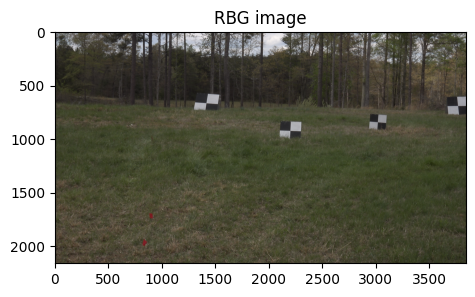

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(20, 3))

try:
  im = axes.imshow(img_bbvisright[:, :, [0,1,2]])
  axes.set_title('RBG image')

  axes.label_outer()
  plt.show()

except Exception as e:
  print(e)

Plotting the LWHSI cube

/tmp/ipykernel_674/3848245576.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.clip((image - lo) / (hi - lo + 1e-12), 0, 1)


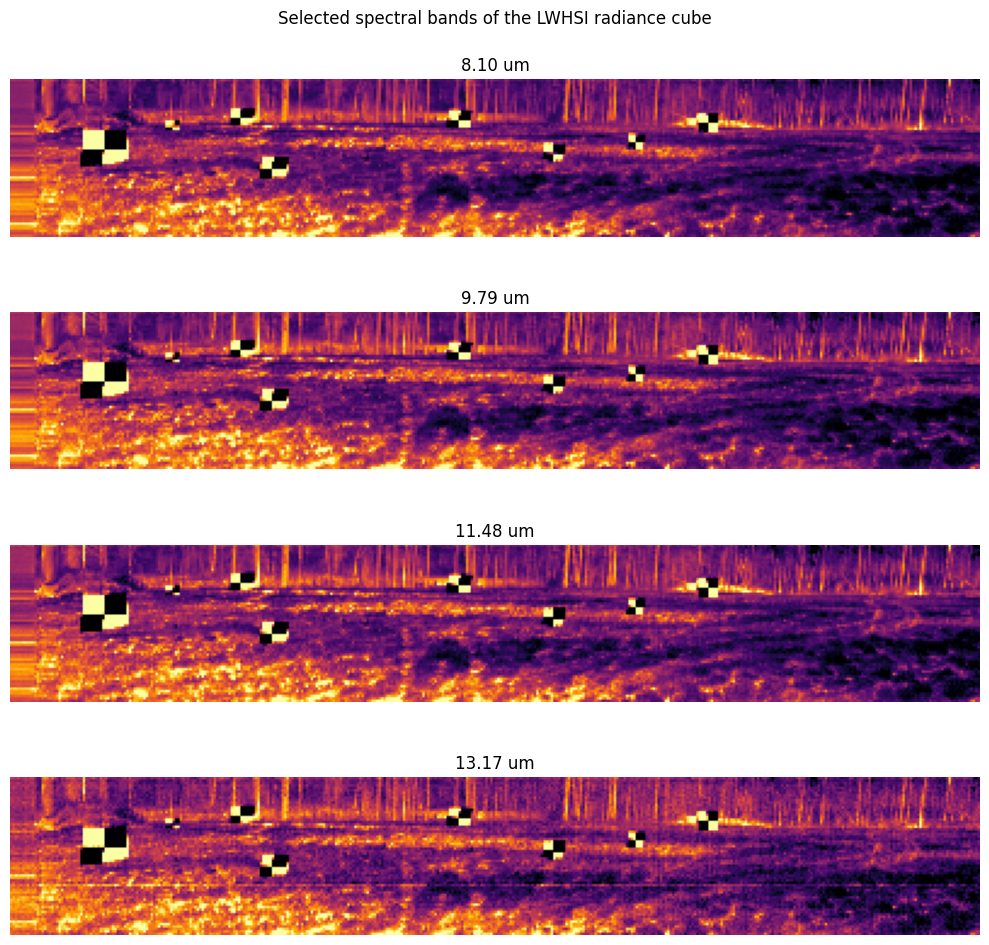

In [ ]:
try:
  if hasattr(img, 'bands') and 'wavelength' in img.metadata:
        wavelengths_um = [float(w) for w in img.metadata['wavelength']]
  else:
      num_bandas = radiance_hsi.shape[2]
      wavelengths_um = np.linspace(8.0, 12.0, num_bandas)

  band_indices = np.linspace(0, len(wavelengths_um) - 1, 4, dtype=int)
  plot_stride = 4

  fig, axes = plt.subplots(len(band_indices), 1, figsize=(10, 10))
  axes = axes.ravel()

  for ax, band_index in zip(axes, band_indices):
      band_image = radiance_hsi[::plot_stride, ::plot_stride, band_index]
      im = ax.imshow(robust_image(band_image), cmap='inferno')
      ax.set_title(f'{wavelengths_um[band_index]:.2f} um')
      ax.axis('off')

  fig.suptitle('Selected spectral bands of the LWHSI radiance cube')
  plt.tight_layout()
  plt.show()
except Exception as e:
    print(f'Error: {e}')

You can select whatever band you want (the images have a total of 256 bands)

/tmp/ipykernel_674/3848245576.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.clip((image - lo) / (hi - lo + 1e-12), 0, 1)


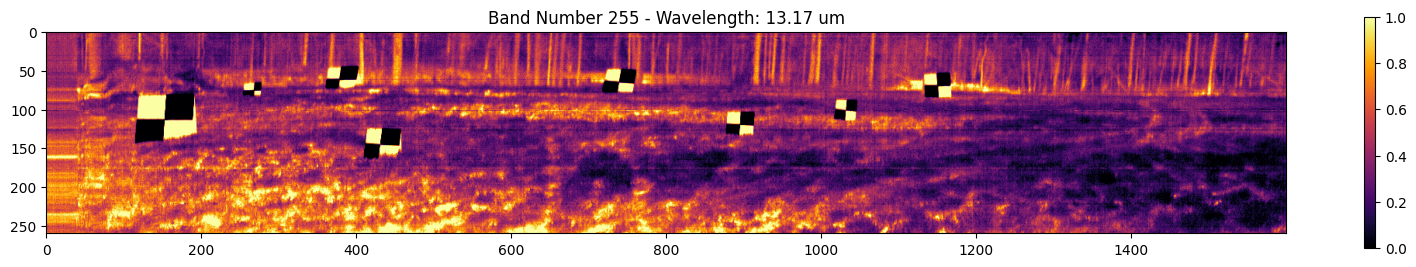

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(20, 3))

# Change the current band with this variable
selected_band = 255

try:

  im = axes.imshow(robust_image(radiance_hsi[:, :, selected_band]), cmap='inferno')
  axes.set_title(f'Band Number {selected_band} - Wavelength: {wavelengths_um[selected_band]:.2f} um')

  axes.label_outer()
  plt.colorbar(im, ax=axes)
  plt.show()

except Exception as e:
  print(e)


Select the pixels you want to plot (image shape is (260,1600,256)) on the image

In [ ]:
# Format is (x,y, # pixel, "Pixel #")

selected_pixels = [
    (180, 1050, 1, "Pixel 1"),
    (40, 250, 2, "Pixel 2"),
    (250, 370, 3, "Pixel 3"),
    (252, 273, 4, "Pixel 4")
]

selected_pixels

[(180, 1050, 1, 'Pixel 1'),
 (40, 250, 2, 'Pixel 2'),
 (250, 370, 3, 'Pixel 3'),
 (252, 273, 4, 'Pixel 4')]

Select the temperature in Kelvin

In [ ]:
# Modify the temperature value with this variable
temperature_k = 300

/tmp/ipykernel_674/3848245576.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.clip((image - lo) / (hi - lo + 1e-12), 0, 1)


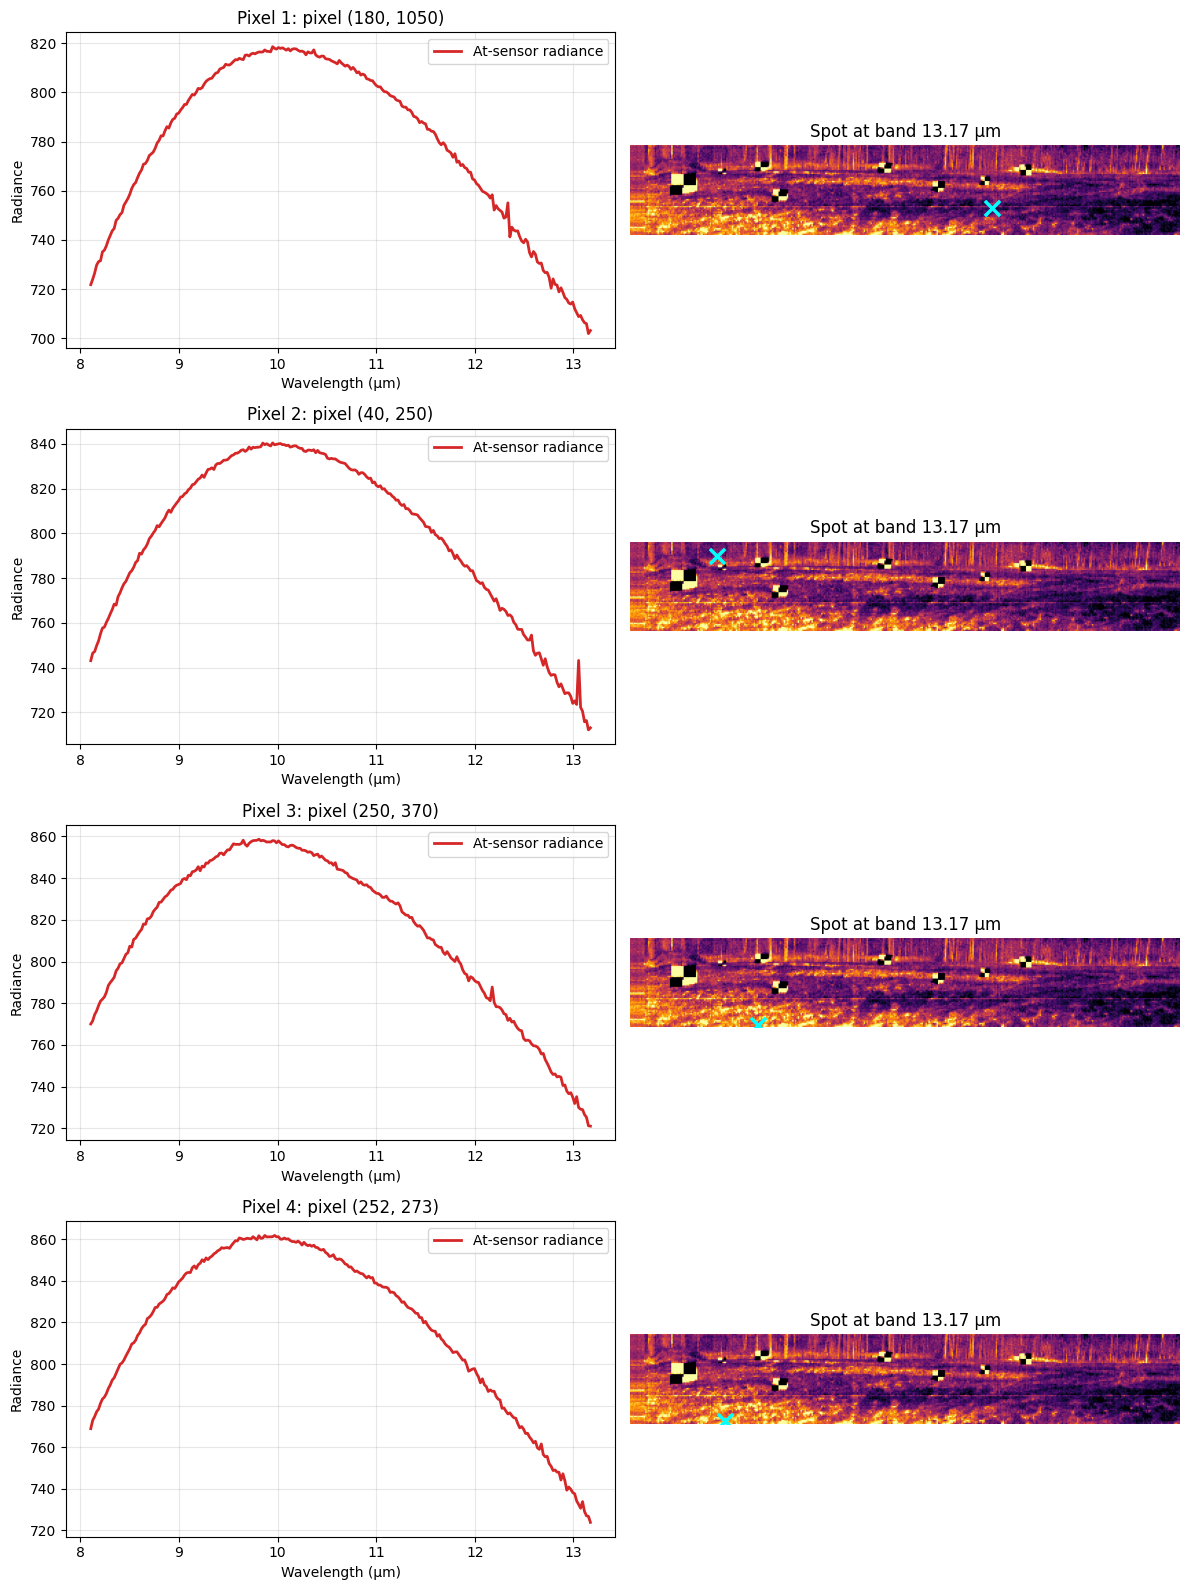

In [ ]:
wavelengths_um = np.array(wavelengths_um)
blackbody_curve=blackbody_radiance(wavelengths_um, temperature_k)

context_image = robust_image(radiance_hsi[::plot_stride, ::plot_stride, selected_band])

fig, axes = plt.subplots(len(selected_pixels), 2, figsize=(12, 4 * len(selected_pixels)))
if len(selected_pixels) == 1:
    axes = axes[None, :]

for row_axes, (row, col, material_id, material_name) in zip(axes, selected_pixels):
    ax_spec, ax_img = row_axes
    ax_spec.plot(wavelengths_um, radiance_hsi[row, col, :].flatten(), color='tab:red', linewidth=2, label='At-sensor radiance')
    ax_spec.set_title(f'{material_name}: pixel ({row}, {col})')
    ax_spec.set_xlabel('Wavelength (µm)')
    ax_spec.set_ylabel('Radiance')
    ax_spec.grid(True, alpha=0.3)
    ax_spec.legend()
    ax_img.imshow(context_image, cmap='inferno', aspect='equal')
    ax_img.scatter(col / plot_stride, row / plot_stride, s=120, marker='x', color='cyan', linewidths=2.5)
    ax_img.set_title(f'Spot at band {wavelengths_um[selected_band]:.2f} µm')
    ax_img.axis('off')

plt.tight_layout()
plt.show()

## LIDAR (DEPTH TRUTH)

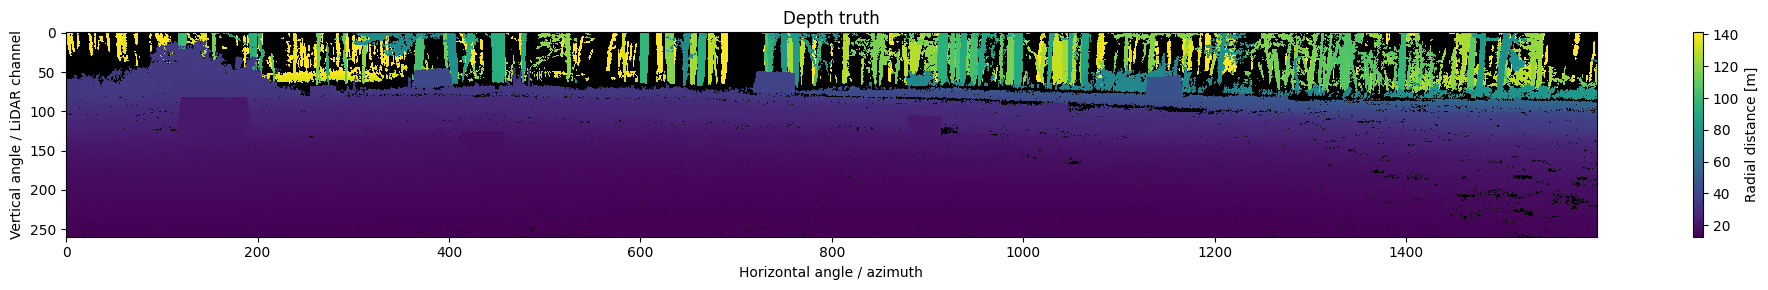

In [ ]:
plot_range_image(
      depth_truth,
      title="Depth truth",
      crop=True,
      inverse_depth=False
  )

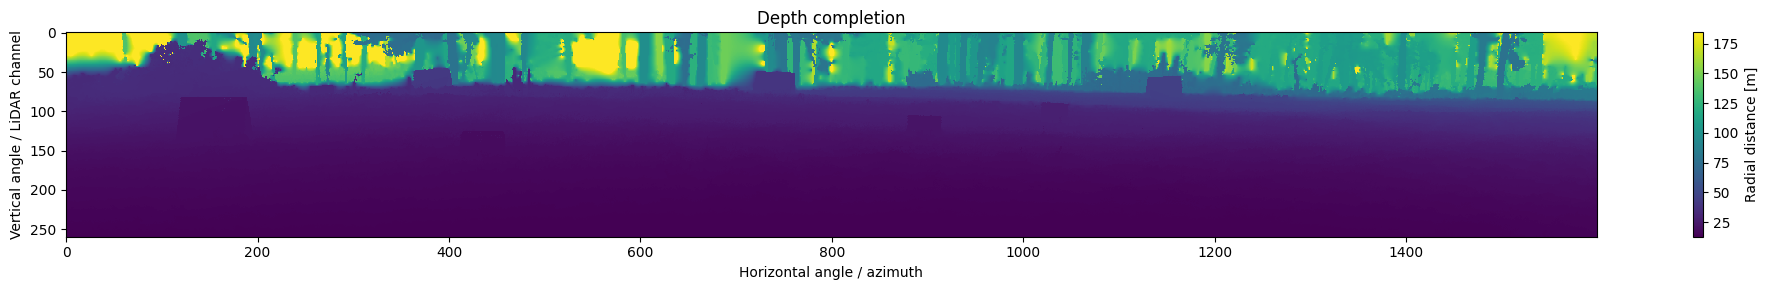

In [ ]:
plot_range_image(
      depth_completion,
      title="Depth completion",
      crop=True,
      inverse_depth=False
  )

## EMISSIVITY TRUTH

Loading reflectance obtained in the Ecostress Spectral Library

In [ ]:
vegetation = sorted(list(Path("/content/").glob("**/vegetation/*.txt")))
soil = sorted(list(Path("/content/").glob("**/soil/*.txt")))
manmade = sorted(list(Path("/content/").glob("**/manmade/*.txt")))

soil_wavelength, soil_emissivity = emissivity_and_wavelength(soil[47])
grass_wavelength, grass_emissivity = emissivity_and_wavelength(vegetation[8])
tree_wavelength, tree_emissivity = emissivity_and_wavelength(manmade[31])
calibrationpoints_wavelength, calibrationpoints_emissivity = emissivity_and_wavelength(manmade[45])
leaves_wavelength, leaves_emissivity = emissivity_and_wavelength(vegetation[1768])

/content/ecostress_spectral/ecostress/soil/soil.entisol.none.unsorted.tir.fgg003.jpl.nicolet.spectrum.txt
/content/ecostress_spectral/ecostress/vegetation/vegetation.grass.unknown.unknown.all.grass.jhu.becknic.spectrum.txt
/content/ecostress_spectral/ecostress/manmade/manmade.generalconstructionmaterial.wood.solid.all.0404uuuwod.jhu.becknic.spectrum.txt
/content/ecostress_spectral/ecostress/manmade/manmade.reflectancetarget.none.solid.tir.ilf-17464-2-2-tc.jpl.nicolet.spectrum.txt
/content/ecostress_spectral/ecostress/vegetation/vegetation.tree.quercus.lobata.tir.vh282.ucsb.nicolet.spectrum.txt


Using K-Means to segment both the RGB and LWHSI images and get the emissivity truth map

In [ ]:
h, w, h2, w2, rgb_centers, labels_rgb, kmeans_lwhsi, labels_lwhsi_2d = segmentation_maps(5, img_bbvisright, radiance_hsi)

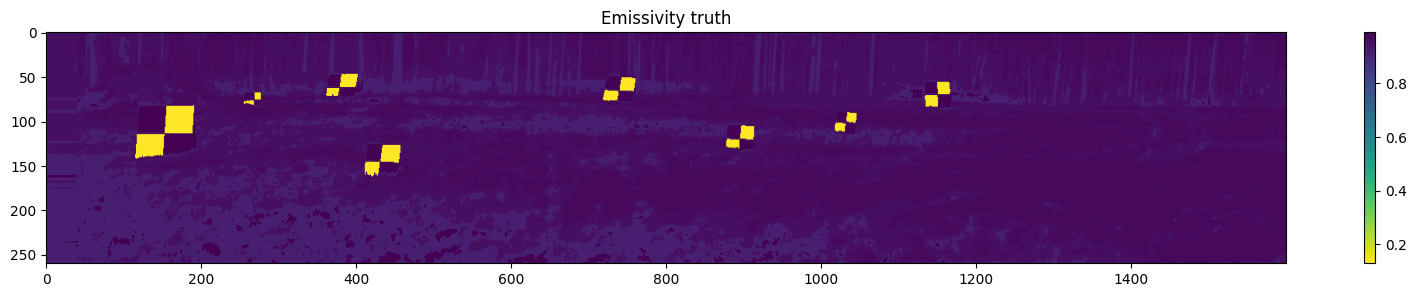

In [ ]:
emissivity_map = emissivity_truth_map(h,
                     w,
                     h2,
                     w2,
                     rgb_centers,
                     labels_rgb,
                     kmeans_lwhsi,
                     labels_lwhsi_2d,
                     calibrationpoints_emissivity,
                     soil_emissivity,
                     leaves_emissivity,
                     tree_emissivity,
                     grass_emissivity,
                     wavelengths_um,
                     calibrationpoints_wavelength,
                     soil_wavelength,
                     leaves_wavelength,
                     tree_wavelength,
                     grass_wavelength)

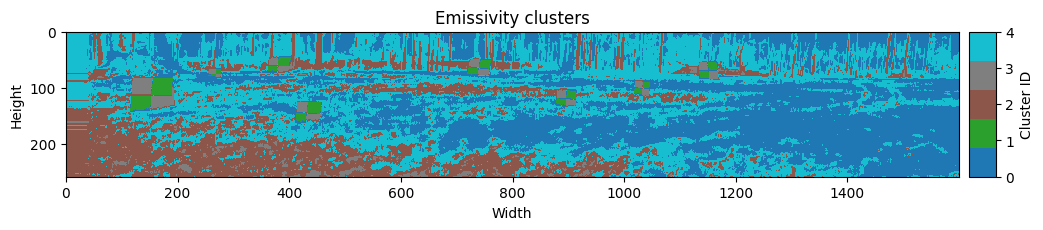

In [ ]:
plot_emissivity_clusters(labels_lwhsi_2d)

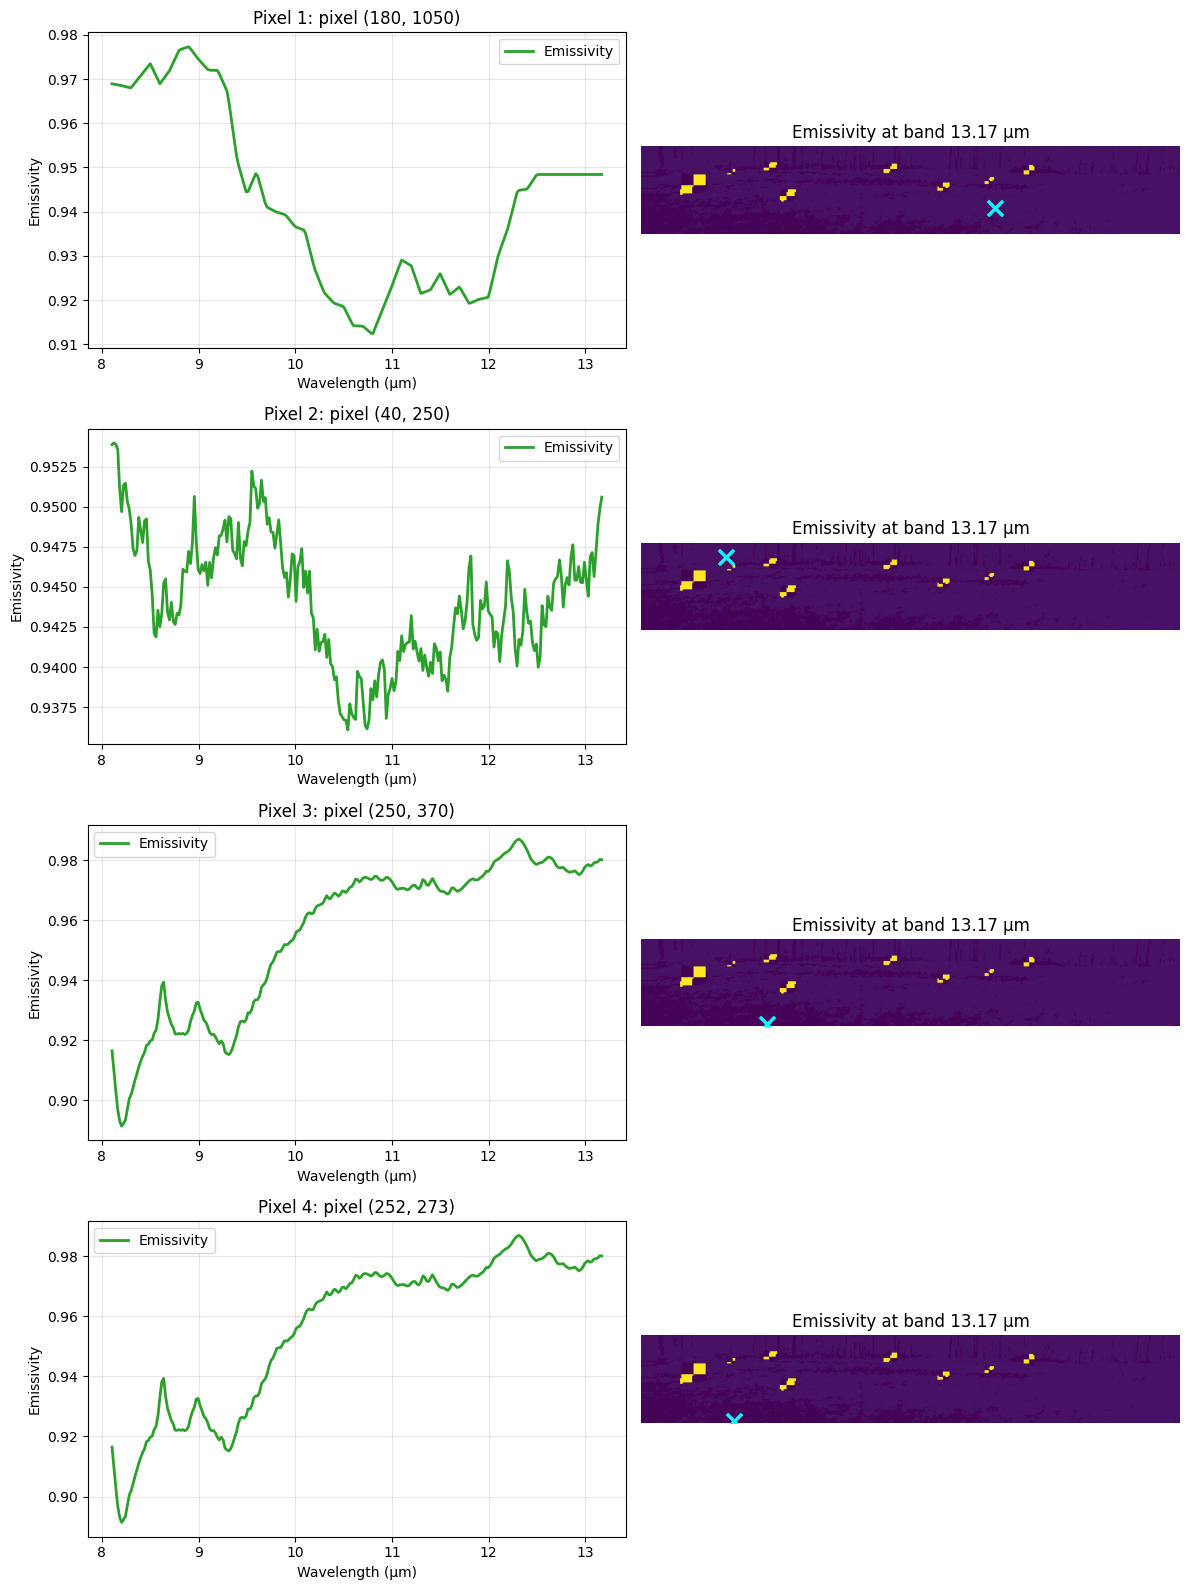

In [ ]:
wavelengths_um = np.array(wavelengths_um)
context_image = emissivity_map[::plot_stride, ::plot_stride, selected_band]

fig, axes = plt.subplots(len(selected_pixels), 2, figsize=(12, 4 * len(selected_pixels)))
if len(selected_pixels) == 1:
    axes = axes[None, :]

for row_axes, (row, col, material_id, material_name) in zip(axes, selected_pixels):
    ax_spec, ax_img = row_axes
    ax_spec.plot(wavelengths_um, emissivity_map[row, col, :].flatten(), color='tab:green', linewidth=2, label='Emissivity')
    ax_spec.set_title(f'{material_name}: pixel ({row}, {col})')
    ax_spec.set_xlabel('Wavelength (µm)')
    ax_spec.set_ylabel('Emissivity')
    ax_spec.grid(True, alpha=0.3)
    ax_spec.legend()
    ax_img.imshow(context_image, cmap='viridis_r', aspect='equal')
    ax_img.scatter(col / plot_stride, row / plot_stride, s=120, marker='x', color='cyan', linewidths=2.5)
    ax_img.set_title(f'Emissivity at band {wavelengths_um[selected_band]:.2f} µm')
    ax_img.axis('off')

plt.tight_layout()
plt.show()

## TEMPERATURE TRUTH

In [59]:
temperature_map = invert_blackbody_temperature(wavelengths_um, radiance_hsi, emissivity=emissivity_map)

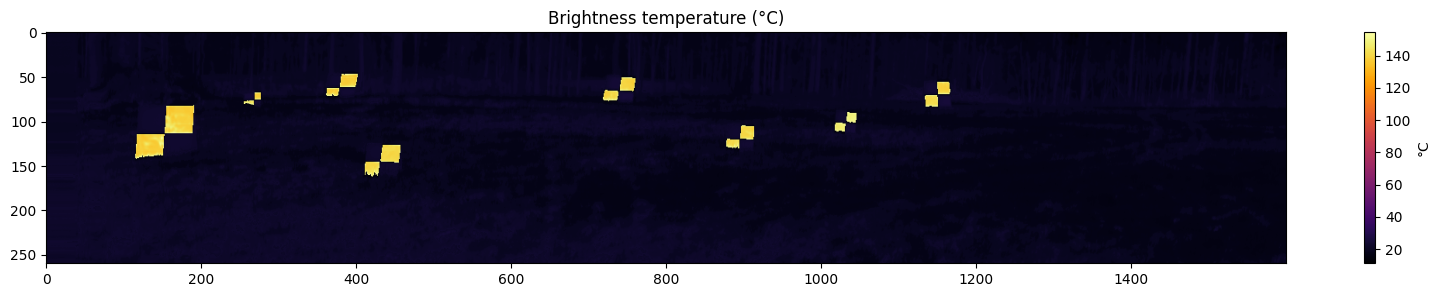

In [70]:
temperature_truth_map(temperature_map[:,:,44], title="Brightness temperature", in_celsius=True)

Applying downwelling

In [66]:
valid_depths = depth_truth[~np.isnan(depth_truth)]
default_depth = np.median(valid_depths) if valid_depths.size > 0 else 10.0

clean_depth = np.nan_to_num(depth_truth, nan=default_depth)

interpolated_attenuation = np.interp(
    wavelengths_um,
    lambda_atm,
    attenuation_map
).astype(np.float32)

transmittance_cube = np.exp(-clean_depth[..., np.newaxis] * interpolated_attenuation[np.newaxis, np.newaxis, :])

panel_mask = (temperature_map[:, :, selected_band] > 0)
num_pixels = np.sum(panel_mask)
l_down_vector = np.mean(l_downwelling, axis=1)
air_blackbody_spectrum = l_downwelling[:, -1]

interpolated_l_down = np.interp(
    wavelengths_um,
    lambda_atm,
    l_down_vector
)

interpolated_emissivity = np.interp(
    wavelengths_um,
    calibrationpoints_wavelength,
    calibrationpoints_emissivity
)

fixed_radiance = radiance_hsi.copy()

if np.any(panel_mask):
    sensor_panel = radiance_hsi[panel_mask, :]
    tau_panel = transmittance_cube[panel_mask, :]

    air_bb_1d = np.reshape(air_blackbody_spectrum, (1, -1))
    l_down_1d = np.reshape(interpolated_l_down, (1, -1))

    emissivity_panel = emissivity_map[panel_mask, :]

    surface_leaving = (sensor_panel - (1.0 - tau_panel) * air_bb_1d) / tau_panel
    pure_emission = surface_leaving - (1.0 - emissivity_panel) * l_down_1d

    fixed_radiance[panel_mask, :] = np.maximum(pure_emission, 1e-12)


fixed_temperature = invert_blackbody_temperature(wavelengths_um, fixed_radiance, emissivity=emissivity_map)

fixed_temp_celsius = fixed_temperature - 273.15

panel_temps_c = fixed_temp_celsius[panel_mask]

/tmp/ipykernel_674/1675476093.py:42: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  surface_leaving = (sensor_panel - (1.0 - tau_panel) * air_bb_1d) / tau_panel


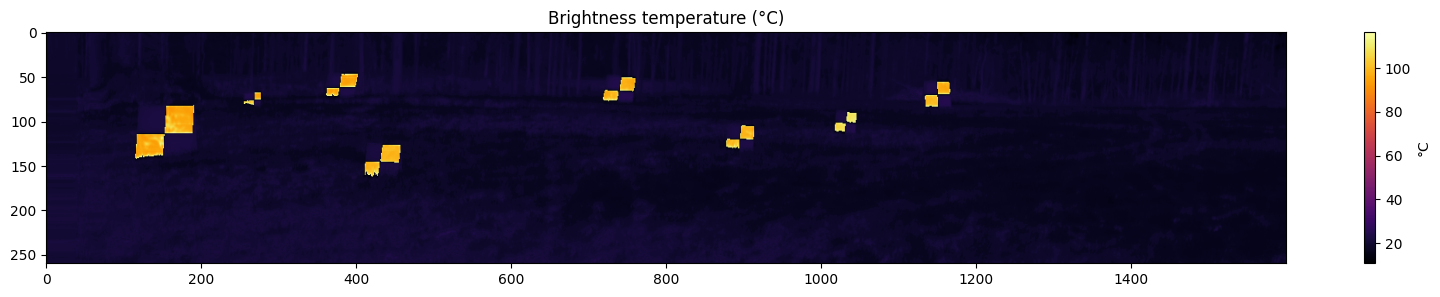

In [71]:
temperature_truth_map(fixed_temperature[:,:,44], title="Brightness temperature", in_celsius=True)

## Constructing the simulated radiance cube

In [73]:
air_temperature_k=295.15;

simulated_hsi=transmittance_cube*(emissivity_map*blackbody_radiance(wavelengths_um, fixed_temperature) + (1-emissivity_map)*interpolated_l_down) + (1-transmittance_cube)*blackbody_radiance(wavelengths_um, air_temperature_k)

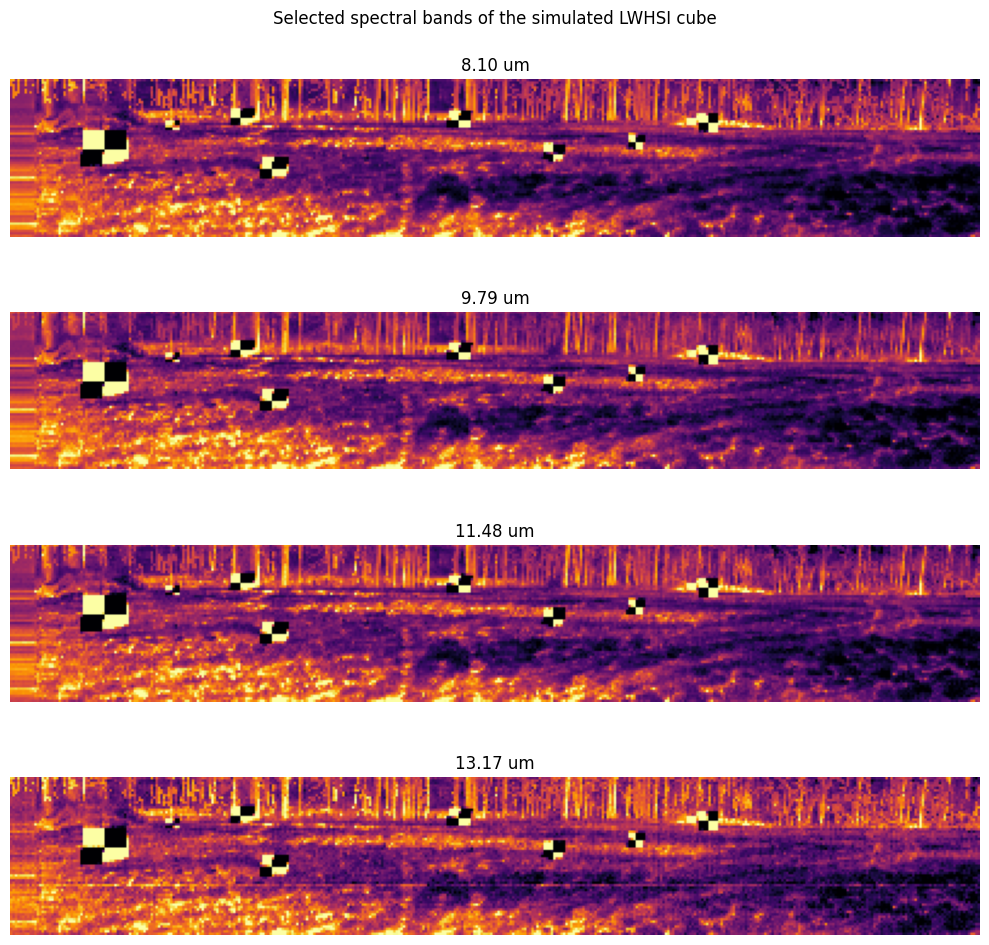

In [77]:
band_indices = np.linspace(0, len(wavelengths_um) - 1, 4, dtype=int)
plot_stride = 4

fig, axes = plt.subplots(len(band_indices), 1, figsize=(10, 10))
axes = axes.ravel()

for ax, band_index in zip(axes, band_indices):
    band_image = simulated_hsi[::plot_stride, ::plot_stride, band_index]
    im = ax.imshow(robust_image(band_image), cmap='inferno')
    ax.set_title(f'{wavelengths_um[band_index]:.2f} um')
    ax.axis('off')

fig.suptitle('Selected spectral bands of the simulated LWHSI cube')
plt.tight_layout()
plt.show()

# Basic Gradiant Descent

In [ ]:
h, w, bands = radiance_hsi.shape

depth = depth_truth

band_idx = int(np.argmin(np.abs(wavelengths_um - 10.0)))

temperature_c = np.mean(fixed_temp_celsius,axis=2)

emissivity = emissivity_map

air_temperature_c = 25.0

downwelling_radiance = l_downwelling[:, -1]

attenuation_db_per_m = attenuation_map

In [ ]:
def blackbody_radianceGD(wavelengths_um, temperature_k):
    """Planck blackbody spectral radiance for all bands, in uW / (sr um cm^2)."""
    h = 6.62607015e-34
    c = 299792458.0
    k = 1.380649e-23

    wavelengths_um = np.asarray(wavelengths_um, dtype=np.float32)
    temperature_k = np.asarray(temperature_k, dtype=np.float32)

    # Reshape wavelengths_um for broadcasting with temperature_k
    wavelength_m = wavelengths_um.reshape((1,) * temperature_k.ndim + wavelengths_um.shape) * 1e-6
    temperature_k_b = temperature_k[..., None]

    # Use temperature_k_b for correct broadcasting
    x = (h * c) / (wavelength_m * k * temperature_k_b)
    radiance_w_m2_sr_um = (2.0 * h * c**2) / (wavelength_m**5 * np.expm1(x)) * 1e-6
    radiance_microflicks = radiance_w_m2_sr_um * MICROFLICK_PER_W_M2

    return radiance_microflicks.astype(np.float32)

def transmittance(depth_map):
    """Atmospheric transmittance for every wavelength using attenuation in dB/m."""
    optical_loss_db = attenuation_db_per_m[None, None, :] * depth_map[:, :, None]
    return (10 ** (-optical_loss_db / 10.0)).astype(np.float32)


def d_blackbody_radiance_d_temperature(wavelengths_um,temperature_k_map):
    """Derivative of blackbody radiance with respect to temperature in Kelvin."""
    h = 6.62607015e-34
    c = 299792458.0
    k = 1.380649e-23

    wavelength_m = wavelengths_um[None, None, :] * 1e-6
    temperature_k_map = temperature_k_map[:, :, None]

    x = (h * c) / (wavelength_m * k * temperature_k_map)
    exp_x = np.exp(x)
    scale = (2.0 * h * c**2) / wavelength_m**5 * 1e-6 * MICROFLICK_PER_W_M2
    derivative = scale * exp_x * x / (temperature_k_map * (exp_x - 1.0) ** 2)
    return derivative.astype(np.float32)


def plot_truth_prediction_error(truth, prediction, title, unit, cmap='viridis'):
    error = np.abs(prediction - truth)
    vmin = min(float(np.nanmin(truth)), float(np.nanmin(prediction)))
    vmax = max(float(np.nanmax(truth)), float(np.nanmax(prediction)))

    truth_masked = np.ma.masked_invalid(truth)
    error_masked = np.ma.masked_invalid(error)

    # Aumentamos el tamaño de la figura (ancho, alto)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # 1. Truth
    im0 = axes[0].imshow(truth_masked, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[0].set_title(f'{title} truth')
    axes[0].axis('off')

    divider0 = make_axes_locatable(axes[0])
    cax0 = divider0.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im0, cax=cax0, label=unit)

    # 2. Prediction
    im1 = axes[1].imshow(prediction, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[1].set_title(f'{title} prediction')
    axes[1].axis('off')

    divider1 = make_axes_locatable(axes[1])
    cax1 = divider1.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im1, cax=cax1, label=unit)

    # 3. Error
    im2 = axes[2].imshow(error_masked, cmap='magma')
    axes[2].set_title(f'{title} absolute error')
    axes[2].axis('off')

    divider2 = make_axes_locatable(axes[2])
    cax2 = divider2.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im2, cax=cax2, label=unit)

    plt.tight_layout()
    plt.show()

In [ ]:
def manual_gradient_descent(
    observed_radiance,
    air_temperature_c,
    downwelling_radiance,
    iterations=800,
    record_every=50,
    initial_emissivity=0.85,
    initial_depth = 10.0,
    initial_temperature_c = 10.0,
    learning_rate_emissivity= 3e2,
    learning_rate_depth = 3e5,
    learning_rate_temperature = 15.0,
    depth_truth=None,
    temperature_truth_c=None,
    emissivity_truth=None,
):
    """Estimate emissivity, depth, and object temperature.

    T_air and the incident downwelling radiance are fixed inputs.
    They are used by the RTE but are not estimated here.
    """
    observed_radiance = np.asarray(
        observed_radiance,
        dtype=np.float32,
    )
    n_bands = observed_radiance.shape[2]
    radiance_scale = np.maximum(
        np.mean(
            observed_radiance,
            axis=2,
            keepdims=True,
        ),
        1.0,
    )

    #Initial Values
    predicted_emissivity = np.full_like(
        observed_radiance,
        initial_emissivity,
        dtype=np.float32,
    )
    predicted_depth = np.full(
        observed_radiance.shape[:2],
        initial_depth,
        dtype=np.float32,
    )
    predicted_temperature_k = np.full(
        observed_radiance.shape[:2],
        initial_temperature_c + 273.15,
        dtype=np.float32,
    )

    # Constant Values
    air_temperature_k = np.array(
        [[air_temperature_c + 273.15]],
        dtype=np.float32,
    )
    air_blackbody = blackbody_radianceGD(
        wavelengths_um, air_temperature_k
    )

    fixed_downwelling = np.asarray(
        downwelling_radiance,
        dtype=np.float32,
    )
    if fixed_downwelling.ndim == 1:
        fixed_downwelling = (
            fixed_downwelling[None, None, :]
        )
    if fixed_downwelling.shape[-1] != n_bands:
        raise ValueError(
            'downwelling_radiance must have one value per band.'
        )
    try:
        fixed_downwelling = np.broadcast_to(
            fixed_downwelling,
            observed_radiance.shape,
        )
    except ValueError as exc:
        raise ValueError(
            'downwelling_radiance must broadcast to '
            'observed_radiance.'
        ) from exc

    attenuation_factor = (
        -(np.log(10.0) / 10.0)
        * attenuation_db_per_m[None, None, :]
    )
    history = []

    for iteration in range(iterations + 1):
        blackbody = blackbody_radianceGD(
            wavelengths_um, predicted_temperature_k
        )
        transmittance_term = transmittance(
            predicted_depth
        )

        # Forward
        surface_leaving = (
            predicted_emissivity * blackbody
            + (1.0 - predicted_emissivity)
            * fixed_downwelling
        )
        prediction = (
            transmittance_term * surface_leaving
            + (1.0 - transmittance_term)
            * air_blackbody
        )


        normalized_error = (
            prediction - observed_radiance
        ) / radiance_scale
        loss = np.mean(normalized_error**2)

        if (
            iteration % record_every == 0
            or iteration == iterations
        ):
            row = {
                'iteration': iteration,
                'normalized_radiance_rmse': float(
                    np.sqrt(loss)
                ),
            }
            if depth_truth is not None:
                row['depth_rmse'] = float(
                    np.sqrt(
                        np.nanmean(
                            (
                                predicted_depth
                                - depth_truth
                            ) ** 2
                        )
                    )
                )
            if temperature_truth_c is not None:
                predicted_temperature_c = (
                    predicted_temperature_k - 273.15
                )
                row['temperature_rmse'] = float(
                    np.sqrt(
                        np.nanmean(
                            (
                                predicted_temperature_c
                                - temperature_truth_c
                            ) ** 2
                        )
                    )
                )
            if emissivity_truth is not None:
                row['emissivity_rmse'] = float(
                    np.sqrt(
                        np.mean(
                            (
                                predicted_emissivity
                                - emissivity_truth
                            ) ** 2
                        )
                    )
                )
            history.append(row)

        if iteration == iterations:
            break

        residual_factor = (
            (2.0 / n_bands)
            * (prediction - observed_radiance)
            / (radiance_scale**2)
        )

        # Gradients
        grad_emissivity = (
            residual_factor
            * transmittance_term
            * (blackbody - fixed_downwelling)
        )

        grad_depth = np.sum(
            residual_factor
            * (surface_leaving - air_blackbody)
            * attenuation_factor
            * transmittance_term,
            axis=2,
        )

        grad_temperature = np.sum(
            residual_factor
            * predicted_emissivity
            * transmittance_term
            * d_blackbody_radiance_d_temperature(
                wavelengths_um, predicted_temperature_k
            ),
            axis=2,
        )

        # New Values
        predicted_emissivity = np.clip(
            predicted_emissivity
            - learning_rate_emissivity
            * grad_emissivity,
            0.6,
            1.0,
        ) #Emisividades bajas
        predicted_depth = np.clip(
            predicted_depth
            - learning_rate_depth * grad_depth,
            0.0,
            140.0,
        )
        predicted_temperature_k = np.clip(
            predicted_temperature_k
            - learning_rate_temperature
            * grad_temperature,
            273.15,
            313.15,
        )
        #Otras metricas
        if iteration % record_every == 0 or iteration == iterations:
            row['grad_depth_mean_abs'] = float(np.mean(np.abs(grad_depth)))
            row['depth_change_from_init'] = float(np.mean(np.abs(predicted_depth - initial_depth)))
            row['grad_emissivity_mean_abs'] = float(np.mean(np.abs(grad_emissivity)))
            row['emissivity_change_from_init'] = float(np.mean(np.abs(predicted_emissivity - initial_emissivity)))
            row['grad_temperature_mean_abs'] = float(np.mean(np.abs(grad_temperature)))
            row['temperature_change_from_init'] = float(np.mean(np.abs(predicted_temperature_k - 273.15 - initial_temperature_c)))

    return {
        'emissivity': predicted_emissivity,
        'depth': predicted_depth,
        'temperature_c': (
            predicted_temperature_k - 273.15
        ),
        'history': history,
    }


## Basic Visualization

In [ ]:
backward_stride = 8

observed_small = radiance_hsi[::backward_stride, ::backward_stride, :]
depth_truth_small = depth[::backward_stride, ::backward_stride]
temperature_truth_small = temperature_c[::backward_stride, ::backward_stride]
emissivity_truth_small = emissivity[::backward_stride, ::backward_stride, :]

inverse_result = manual_gradient_descent(
    observed_small,
    air_temperature_c=air_temperature_c,
    downwelling_radiance=downwelling_radiance,
    iterations=1000,
    record_every=50,
    depth_truth=depth_truth_small,
    temperature_truth_c=np.squeeze(temperature_truth_small),
    emissivity_truth=emissivity_truth_small,
)

#  temperature_truth_c=temperature_truth_small,

print('Estimated emissivity:', inverse_result['emissivity'].shape)
print('Estimated depth:', inverse_result['depth'].shape)
print('Estimated temperature:', inverse_result['temperature_c'].shape)
print('Final metrics:', inverse_result['history'][-1])


Estimated emissivity: (33, 200, 256)
Estimated depth: (33, 200)
Estimated temperature: (33, 200)
Final metrics: {'iteration': 1000, 'normalized_radiance_rmse': 0.004664963111281395, 'depth_rmse': 58.98375107065647, 'temperature_rmse': 9.080615997314453, 'emissivity_rmse': 0.2137518674135208}


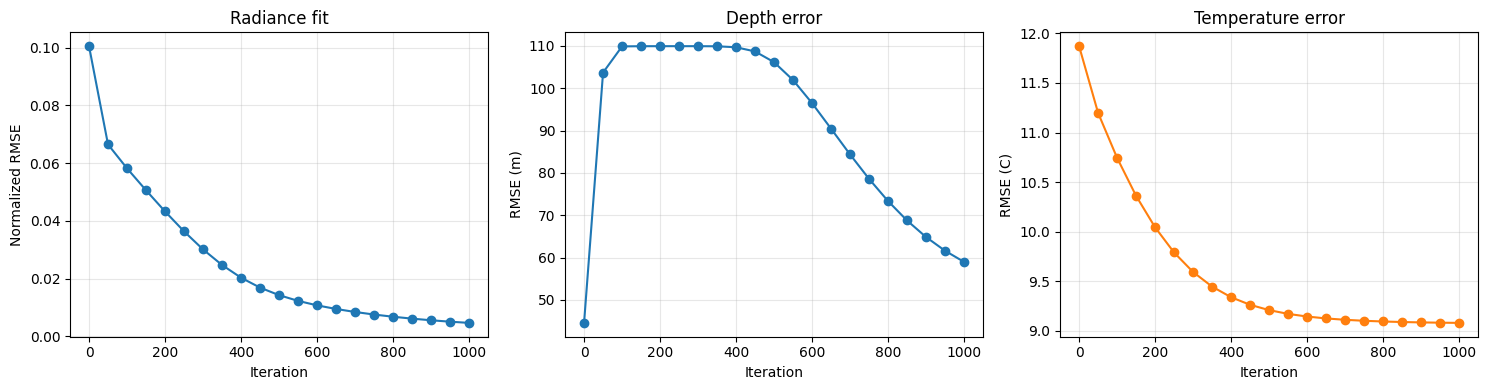

In [ ]:
history = inverse_result['history']
iterations = [row['iteration'] for row in history]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(iterations, [row['normalized_radiance_rmse'] for row in history], marker='o')
axes[0].set_title('Radiance fit')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Normalized RMSE')
axes[0].grid(True, alpha=0.3)

axes[1].plot(iterations, [row['depth_rmse'] for row in history], marker='o', color='tab:blue')
axes[1].set_title('Depth error')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('RMSE (m)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(iterations, [row['temperature_rmse'] for row in history], marker='o', color='tab:orange')
axes[2].set_title('Temperature error')
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('RMSE (C)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


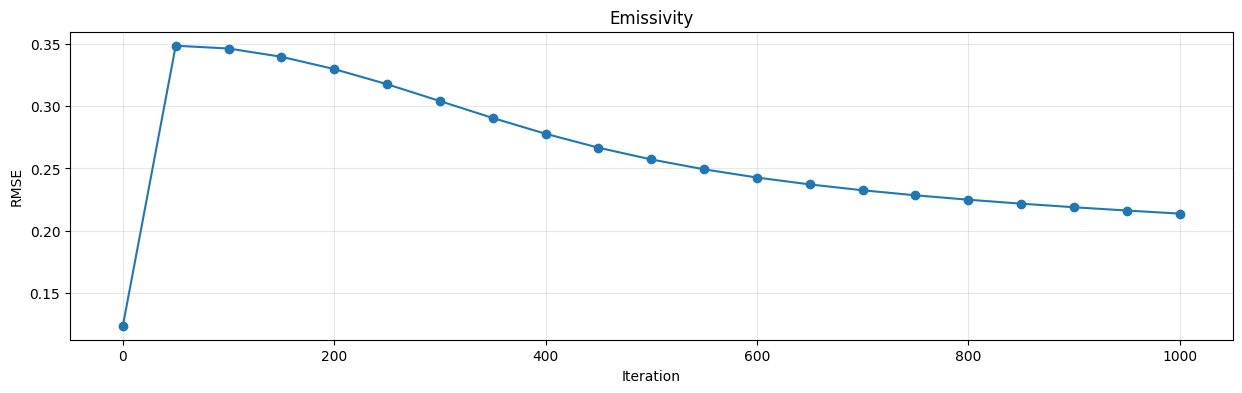

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(15, 4))
axes.plot(iterations, [row['emissivity_rmse'] for row in history], marker='o')
axes.set_title('Emissivity')
axes.set_xlabel('Iteration')
axes.set_ylabel('RMSE')
axes.grid(True, alpha=0.3)

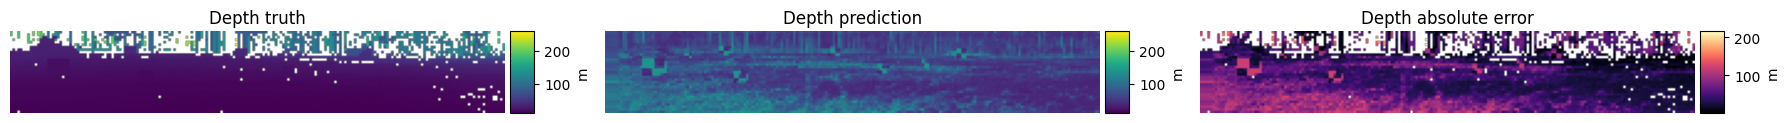

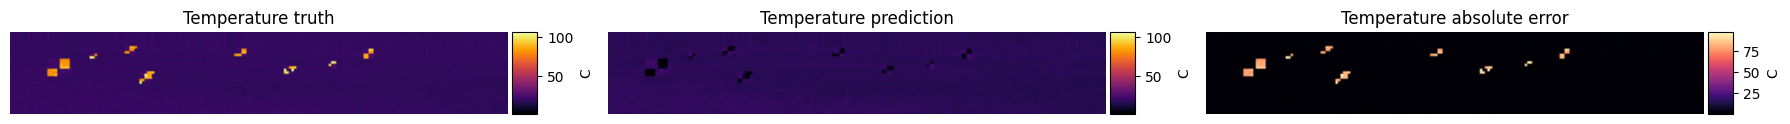

In [ ]:
plot_truth_prediction_error(depth_truth_small, inverse_result['depth'], 'Depth', 'm')
plot_truth_prediction_error(
    np.squeeze(temperature_truth_small), inverse_result['temperature_c'], 'Temperature', 'C', cmap='inferno'
)

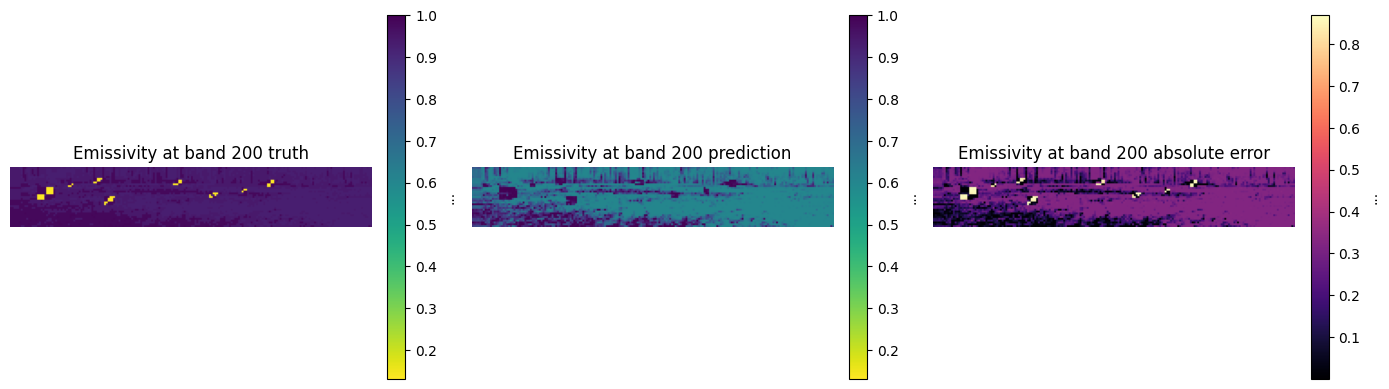

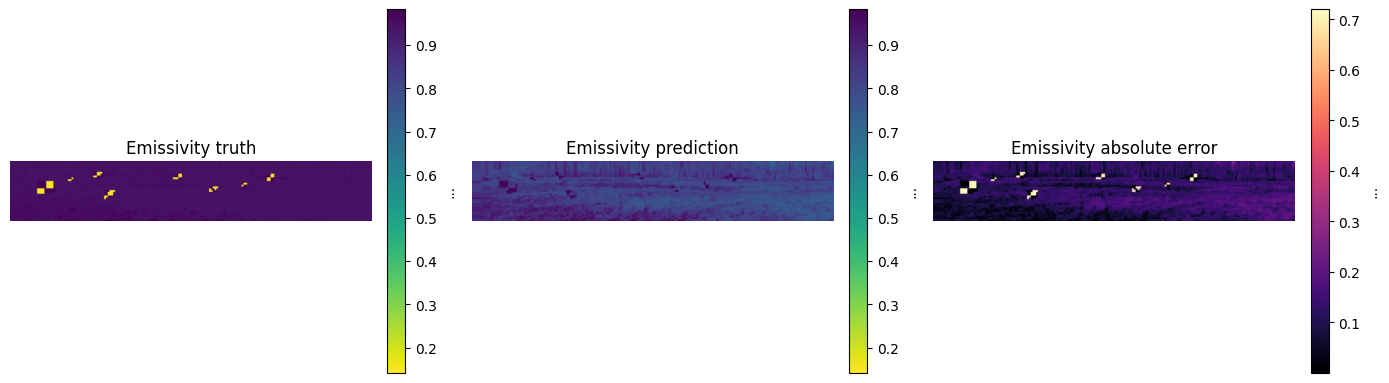

In [ ]:
N=200
plot_truth_prediction_error(emissivity_truth_small[:,:,N], inverse_result['emissivity'][:,:,N], f'Emissivity at band {N}', '...', cmap='viridis_r')
plot_truth_prediction_error(np.mean(emissivity_truth_small,axis=2), np.mean(inverse_result['emissivity'],axis=2), 'Emissivity', '...', cmap='viridis_r')

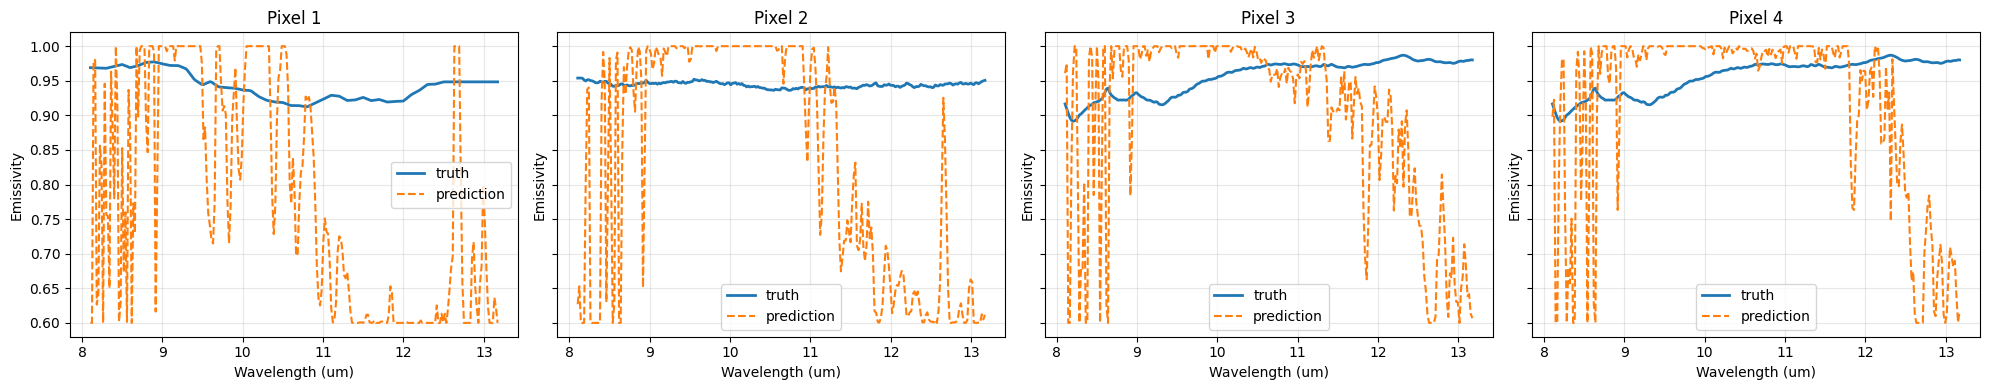

Selected-pixel emissivity RMSE: 0.18363666534423828


In [ ]:
selected_rows = np.array([pixel[0] for pixel in selected_pixels])
selected_cols = np.array([pixel[1] for pixel in selected_pixels])
selected_names = [pixel[3] for pixel in selected_pixels]

selected_small_rows = selected_rows // backward_stride
selected_small_cols = selected_cols // backward_stride
emissivity_truth_pixels = emissivity[selected_rows, selected_cols, :]
emissivity_prediction_pixels = inverse_result['emissivity'][selected_small_rows, selected_small_cols, :]

fig, axes = plt.subplots(1, len(selected_names), figsize=(5 * len(selected_names), 4), sharey=True)
if len(selected_names) == 1:
    axes = [axes]

for i, (ax, material_name) in enumerate(zip(axes, selected_names)):
    ax.plot(wavelengths_um, emissivity_truth_pixels[i, :], label='truth', linewidth=2)
    ax.plot(wavelengths_um, emissivity_prediction_pixels[i, :], label='prediction', linestyle='--')
    ax.set_title(material_name)
    ax.set_xlabel('Wavelength (um)')
    ax.set_ylabel('Emissivity')
    #ax.set_ylim(0.55, 1.02)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

print('Selected-pixel emissivity RMSE:', float(np.sqrt(np.mean((emissivity_prediction_pixels - emissivity_truth_pixels) ** 2))))
